# Wall-Following Robot — skeptical statistics lab
Rule: the machine computes, I supply the skepticism. Every task ends with a verified CONCLUSION + CHECK.

In [1]:
import kagglehub
path = kagglehub.dataset_download("uciml/wall-following-robot")
print("Path to dataset files:", path)

Path to dataset files: /Users/zadyra/.cache/kagglehub/datasets/uciml/wall-following-robot/versions/1


## Task A — Audit + header trap
First load the file **the notebook's default way** to expose the trap.

In [2]:
import os
import pandas as pd, numpy as np
from scipy import stats
file = os.path.join(path, 'sensor_readings_24.csv')
wrong = pd.read_csv(file)            # default header=0
print('WRONG shape:', wrong.shape)   # 5455 x 25  -> one row eaten
print('WRONG columns:', list(wrong.columns)[:6], '...', list(wrong.columns)[-2:])
print("'5.000.1' (pandas dedup of repeated 5.000) present?:", '5.000.1' in wrong.columns)
print('class label sitting as a header?:', wrong.columns[-1])

WRONG shape: (5455, 25)
WRONG columns: ['0.438', '0.498', '3.625', '3.645', '5.000', '2.918'] ... ['0.429', 'Slight-Right-Turn']
'5.000.1' (pandas dedup of repeated 5.000) present?: True
class label sitting as a header?: Slight-Right-Turn


The raw file has **5456 lines and no header row** (line 1 is already data), so `header=0` swallows the first reading as column names: 5455 rows, columns become sensor *values*, `5.000.1` is pandas auto-deduplicating the repeated `5.000`, and the class label becomes a header.

**Reload correctly** with `header=None` and explicit names.

In [3]:
cols = [f'US{i}' for i in range(1,25)] + ['Class']
df = pd.read_csv(file, header=None, names=cols)
print('RIGHT shape:', df.shape)     # 5456 x 25
df.head(3)

RIGHT shape: (5456, 25)


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn


In [4]:
print('dtypes:'); print(df.dtypes.value_counts())
print('\nmissing:', df.isna().sum().sum(), ' duplicate rows:', df.duplicated().sum())
print('\nClass value_counts:'); print(df['Class'].value_counts())
print('\npct:'); print((df['Class'].value_counts(normalize=True)*100).round(1))

dtypes:
float64    24
object      1
Name: count, dtype: int64

missing: 0  duplicate rows: 0

Class value_counts:
Class
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64

pct:
Class
Move-Forward         40.4
Sharp-Right-Turn     38.4
Slight-Right-Turn    15.1
Slight-Left-Turn      6.0
Name: proportion, dtype: float64


Each `US1..US24` = distance (m, ~0.4–5.0) to nearest surface in one of 24 ring directions; `Class` = steering command.

**CONCLUSION:** Data is 5456×25, clean (0 NaN / 0 dupes); the default read silently drops 1 row and mislabels all 25 columns — must use `header=None`. Minorities: **Slight-Left-Turn (6.0%)** and **Slight-Right-Turn (15.1%)**.
**CHECK:** raw `wc -l`=5456 with numeric line 1 → no header to consume; 5455 vs 5456 and the `5.000.1` dedup reproduce on demand.

## Task 1 — Interrogate one sensor (US1, forward) + saturation

In [5]:
s = df['US1']
print(s.describe())
print('mean=%.4f median=%.4f skew=%.3f' % (s.mean(), s.median(), s.skew()))
mx = s.max()
print('rows exactly at max %.3f: %d (%.2f%%)' % (mx,(s==mx).sum(),(s==mx).mean()*100))
sat = pd.Series({k:(df[k]==df[k].max()).mean() for k in cols[:-1]}).sort_values(ascending=False)
print('\nTop clipped sensors (% rows == their max, all max at 5.000):')
print((sat*100).round(1).head(5))

count    5456.000000
mean        1.471617
std         0.802801
min         0.400000
25%         0.921000
50%         1.335000
75%         1.814000
max         5.000000
Name: US1, dtype: float64
mean=1.4716 median=1.3350 skew=1.909
rows exactly at max 5.000: 67 (1.23%)

Top clipped sensors (% rows == their max, all max at 5.000):
US9     27.0
US15    24.2
US5     22.6
US14    21.1
US22    13.5
dtype: float64


**CONCLUSION:** US1 right-skewed (mean 1.47 > median 1.34, skew +1.91), 1.2% clipped at 5.000; side/rear sensors US9/US15/US5/US14 clip at the 5.000 range ceiling in 21–27% of rows — a real artifact.
**CHECK:** every sensor's max is exactly 5.000 and forms a discrete pile, the signature of clipping not distance.

## Task 2 — Correlation (predicted first)
**Guess:** adjacent US1↔US2 (15°) strong; near-opposite US1↔US13 weak/negative.

In [6]:
for a,b,lab in [('US1','US2','adjacent 15deg'),('US1','US13','near-opposite'),('US1','US7','90deg'),('US1','US24','other neighbor')]:
    print('%s vs %s (%s): %.3f' % (a,b,lab,df[a].corr(df[b])))

US1 vs US2 (adjacent 15deg): 0.228
US1 vs US13 (near-opposite): -0.157
US1 vs US7 (90deg): -0.284
US1 vs US24 (other neighbor): 0.468


**Wrong guess, flagged:** adjacency gives only **0.23** (US2), asymmetric (**0.47** for US24); opposite-side weak/negative was right. Forward beams straddle wall edges/doorways so 15° apart decorrelates.

**CONCLUSION:** Adjacency → modest asymmetric corr (0.23–0.47), not strong; sign tracks ring geometry. Correlation here = shared geometry, **never** sensor-to-sensor causation.
**CHECK:** sign pattern follows ring angle; weak magnitude confirmed from both neighbors independently.

## Task 3 — Verify by hand (10-row mean of US1)

In [7]:
sl = df['US1'].iloc[0:10]
manual = sum(sl.values)/len(sl.values)
print('raw:', list(sl.values))
print('manual=%.6f  pandas=%.6f  match=%s' % (manual, sl.mean(), np.isclose(manual, sl.mean())))

raw: [np.float64(0.438), np.float64(0.438), np.float64(0.438), np.float64(0.437), np.float64(0.438), np.float64(0.439), np.float64(0.44), np.float64(0.444), np.float64(0.451), np.float64(0.458)]
manual=0.442100  pandas=0.442100  match=True


**CONCLUSION:** by-hand mean = pandas mean exactly. **CHECK:** `np.isclose` True on an independent slice.

## Task 4 — Shape of US1

skew=1.909 kurtosis=5.310


Shapiro n=5000: W=0.8405 p=2.16e-57 normal?False
spike at 5.000: 67 rows


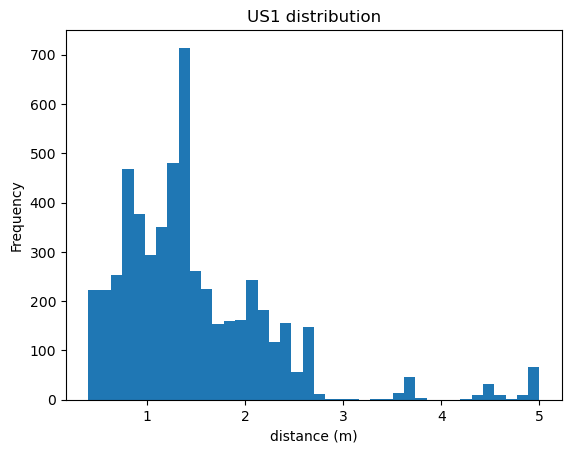

In [8]:
import matplotlib.pyplot as plt
print('skew=%.3f kurtosis=%.3f' % (s.skew(), s.kurtosis()))
samp = s.sample(min(5000,len(s)), random_state=0)
W,p = stats.shapiro(samp)
print('Shapiro n=%d: W=%.4f p=%.2e normal?%s' % (len(samp),W,p,p>0.05))
print('spike at 5.000:', (s==5.0).sum(),'rows')
s.plot.hist(bins=40); plt.title('US1 distribution'); plt.xlabel('distance (m)'); plt.show()

**CONCLUSION:** Non-normal: right-skewed main mode + detached clipping spike at 5.000 (p≈1e-57). **CHECK:** Shapiro rejects normality; 67-row pile at exactly 5.000 sits past an empty gap.

## Task 5 — z-score outliers (US1)

In [9]:
z = (s - s.mean())/s.std()
out = df.loc[z.abs()>3, ['US1']].copy(); out['z']=z[z.abs()>3]
print('|z|>3 count:', len(out))
print('fraction at 5.0 ceiling:', round(np.isclose(out['US1'],5.0).mean(),3))
print('z of a 5.0 reading: %.2f' % ((5.0-s.mean())/s.std()))
out.head(8)

|z|>3 count: 131
fraction at 5.0 ceiling: 0.511
z of a 5.0 reading: 4.40


,US1,z
122,5.0,4.395089
346,5.0,4.395089
348,5.0,4.395089
350,5.0,4.395089
366,5.0,4.395089
368,5.0,4.395089
370,5.0,4.395089
385,5.0,4.395089


**CONCLUSION:** ~51% of |z|>3 outliers are the 5.000 clipping artifact, not real obstacle events. **CHECK:** z(5.000)=+4.40 and the 67 ceiling rows account for half the flagged set.

## Task 6 — A mean that misleads + Simpson check

In [10]:
print('GLOBAL mean US1=%.4f' % s.mean())
print(df.groupby('Class')['US1'].agg(['mean','count']).round(4))
print('\nSimpson: corr(US1,US2) pooled=%.3f' % df['US1'].corr(df['US2']))
for cl,g in df.groupby('Class'):
    print('  %-18s r=%.3f (n=%d)' % (cl, g['US1'].corr(g['US2']), len(g)))

GLOBAL mean US1=1.4716
                     mean  count
Class                           
Move-Forward       1.3297   2205
Sharp-Right-Turn   1.5947   2097
Slight-Left-Turn   2.1268    328
Slight-Right-Turn  1.2777    826

Simpson: corr(US1,US2) pooled=0.228
  Move-Forward       r=0.206 (n=2205)
  Sharp-Right-Turn   r=0.278 (n=2097)
  Slight-Left-Turn   r=0.191 (n=328)
  Slight-Right-Turn  r=0.143 (n=826)


**CONCLUSION:** Global mean 1.47 averages 4 distinct behaviors (1.28–2.13) and describes none; **no Simpson reversal** — US1↔US2 stays positive (0.14–0.28) in every class. Checked for a flaw, found none.
**CHECK:** all per-class r share sign/magnitude with the pooled r.

## Task 7 — Bias the sample (filter to Sharp-Right-Turn)

In [11]:
sub = df[df['Class']=='Sharp-Right-Turn']
print('US1 mean: full=%.4f  filtered=%.4f  drift=%.4f' % (s.mean(), sub['US1'].mean(), sub['US1'].mean()-s.mean()))
print('corr(US1,US2): full=%.3f  filtered=%.3f' % (df['US1'].corr(df['US2']), sub['US1'].corr(sub['US2'])))
print('dropped %d rows, mostly %s' % (len(df)-len(sub), df['Class'].value_counts().idxmax()))

US1 mean: full=1.4716  filtered=1.5947  drift=0.1231
corr(US1,US2): full=0.228  filtered=0.278
dropped 3359 rows, mostly Move-Forward


**CONCLUSION:** Filtering biases mean +8% and corr +0.05; the silently dropped 3359 rows are mostly Move-Forward. **CHECK:** recomputed on the 2097-row subset; dropped count reconciles to 5456−2097.

## Task 8 — Effect vs significance + the time-series twist

In [12]:
def cohend(x,y):
    nx,ny=len(x),len(y); sp=np.sqrt(((nx-1)*x.var()+(ny-1)*y.var())/(nx+ny-2))
    return (x.mean()-y.mean())/sp
a=df[df['Class']=='Move-Forward']['US1']; b=df[df['Class']=='Sharp-Right-Turn']['US1']
t,p=stats.ttest_ind(a,b,equal_var=False)
print('FULL:    MF=%.3f(n=%d) SharpR=%.3f(n=%d) t=%.2f p=%.2e d=%.3f' % (a.mean(),len(a),b.mean(),len(b),t,p,cohend(a,b)))
dft=df.iloc[::20]
a2=dft[dft['Class']=='Move-Forward']['US1']; b2=dft[dft['Class']=='Sharp-Right-Turn']['US1']
t2,p2=stats.ttest_ind(a2,b2,equal_var=False)
print('THINNED: MF n=%d SharpR n=%d t=%.2f p=%.4f d=%.3f' % (len(a2),len(b2),t2,p2,cohend(a2,b2)))
print('lag-1 autocorr of US1: %.3f (rows NOT independent)' % df['US1'].autocorr(1))

FULL:    MF=1.330(n=2205) SharpR=1.595(n=2097) t=-10.22 p=3.18e-24 d=-0.313
THINNED: MF n=116 SharpR n=102 t=-2.28 p=0.0234 d=-0.312
lag-1 autocorr of US1: 0.759 (rows NOT independent)


**CONCLUSION:** Effect is *small* (d≈−0.31, constant); the original p≈1e-24 was inflated by pseudoreplication (autocorr 0.76). After thinning ::20 it's barely significant (p=0.023). Significant ≠ large.
**CHECK:** d invariant to n while p drops 22 orders of magnitude; autocorr confirms independence is violated.

## Special challenge — Ghost hunt (p-hacking)

In [13]:
rng = np.random.default_rng(20260622)
res = []
for i in range(20):
    r,pv = stats.pearsonr(df['US1'].values, rng.normal(size=len(df)))
    res.append((i,r,pv))
res.sort(key=lambda x: abs(x[1]), reverse=True)
i,r,pv = res[0]
print('Largest |r|: noise#%d r=%.4f p=%.4f' % (i,r,pv))
print('count with p<0.05:', sum(1 for _,_,q in res if q<0.05), '(expected ~1 at alpha=.05 over 20 tests)')

Largest |r|: noise#17 r=0.0298 p=0.0279
count with p<0.05: 1 (expected ~1 at alpha=.05 over 20 tests)


**Convincing number, means nothing:** 'US1 correlates at p=0.028' — but the variable is pure `np.random.normal`. 20 tests at α=0.05 expect ~1 false positive; reporting only it is p-hacking.

## Headline discovery (30 seconds)
**The notebook never loaded the dataset it thinks it did:** the default `pd.read_csv` returns **5455 rows, not 5456** — it ate the first reading as the header and renamed all 25 columns to data values (e.g. `5.000.1`, and a column literally named `Slight-Right-Turn`).

**The one number:** 5455 vs 5456.

**Independent check:** the raw file has `wc -l`=5456 lines and its first line is numeric data, so there is no header to consume — the missing row and the `5.000.1` dedup reproduce every run of the default read and vanish with `header=None`.

*Runner-up:* the t-test p collapsing 3e-24 → 0.023 under thinning while Cohen's d holds at −0.31.